<a href="https://colab.research.google.com/github/samweberds/network-intrusion-detection-nsl-kdd/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls

KDDTrain+_20Percent.txt  sample_data


In [ ]:
import pandas as pd

cols = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
"wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
"root_shell","su_attempted","num_root","num_file_creations","num_shells",
"num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
"srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
"same_srv_rate","diff_srv_rate","srv_diff_srv_rate","dst_host_count",
"dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
"dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
"label","difficulty"]

df = pd.read_csv("KDDTrain+_20Percent.txt", names=cols)
print(df.shape)
df.head()

(25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
df["label"].value_counts().head(10)

,count
label,
normal,13449
neptune,8282
ipsweep,710
satan,691
portsweep,587
smurf,529
nmap,301
back,196
teardrop,188


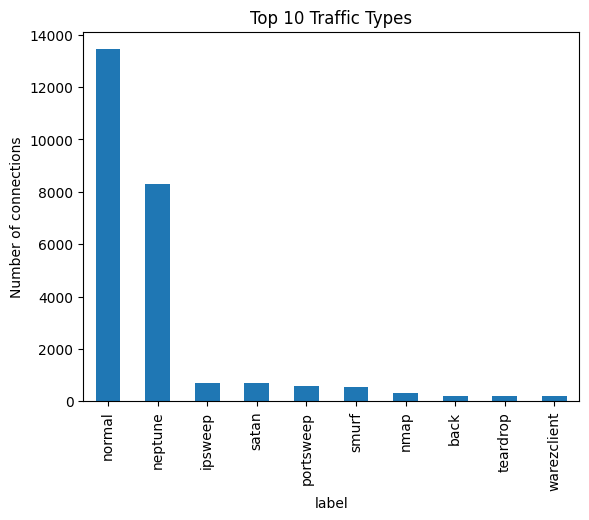

In [ ]:
import matplotlib.pyplot as plt
df["label"].value_counts().head(10).plot(kind="bar", title="Top 10 Traffic Types")
plt.ylabel("Number of connections")
plt.show()

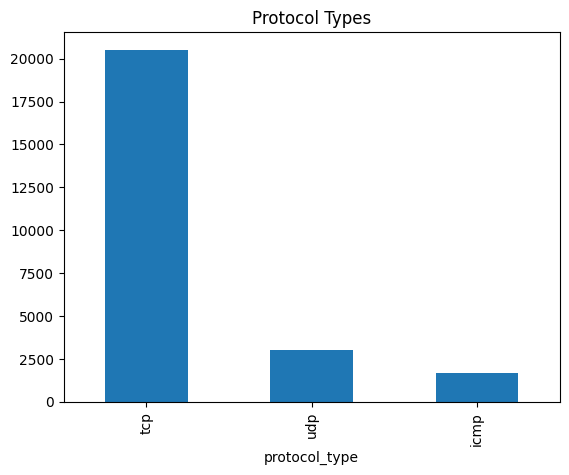

In [ ]:
df["protocol_type"].value_counts().plot(kind="bar", title="Protocol Types")
plt.show()

In [ ]:
df["is_attack"] = (df["label"] != "normal").astype(int)
df["is_attack"].value_counts()

,count
is_attack,
0,13449
1,11743


In [ ]:
df = df.drop(columns=["difficulty"])
df.shape

(25192, 43)

In [ ]:
df.dtypes[df.dtypes == "object"]

,0
protocol_type,object
service,object
flag,object
label,object


In [ ]:
df_encoded = pd.get_dummies(df, columns=["protocol_type", "service", "flag"])
df_encoded.shape

(25192, 120)

In [ ]:
df_encoded = df_encoded.drop(columns=["label"])
df_encoded.shape

(25192, 119)

In [ ]:
X = df_encoded.drop(columns=["is_attack"])
y = df_encoded["is_attack"]
print(X.shape, y.shape)

(25192, 118) (25192,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(20153, 118) (5039, 118)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape, X_test_scaled.shape)

(20153, 118) (5039, 118)


In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = log_model.predict(X_test_scaled)
y_pred[:10]

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 1])

In [17]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.975590394919627


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      2674
      Attack       0.98      0.97      0.97      2365

    accuracy                           0.98      5039
   macro avg       0.98      0.98      0.98      5039
weighted avg       0.98      0.98      0.98      5039



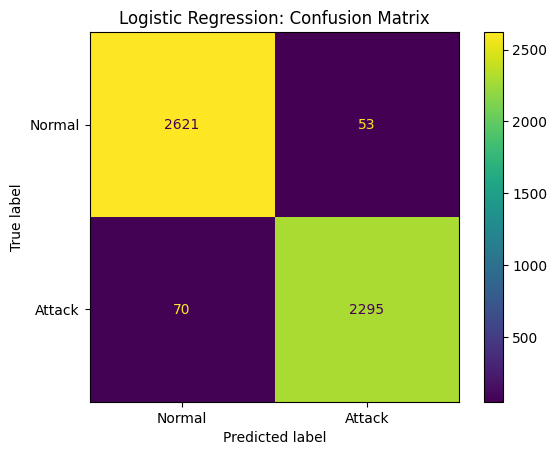

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Normal", "Attack"])
plt.title("Logistic Regression: Confusion Matrix")
plt.show()